<a href="https://colab.research.google.com/github/hytt25/learning/blob/main/video.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import kagglehub
path = kagglehub.dataset_download("datasnaek/youtube-new")

Using Colab cache for faster access to the 'youtube-new' dataset.


### Analyzing Tags and Average Likes

First, we need to extract and clean the individual tags from the 'tags' column. Each video can have multiple tags, often separated by pipes (`|`). We will process these tags, count their occurrences, and then calculate the average likes for videos associated with the most frequent tags.

In [8]:
import pandas as pd
from collections import Counter

# Ensure 'tags' column exists and handle potential NaN values
# Also ensure 'likes' is numeric, which should have been handled in previous steps

# Drop rows where 'tags' or 'likes' are missing for this analysis
df_tags_likes = df.dropna(subset=['tags', 'likes']).copy()

# Process tags: split by '|', clean whitespace, convert to lowercase
def extract_and_clean_tags(tags_string):
    if isinstance(tags_string, str):
        return [tag.strip().lower() for tag in tags_string.split('|') if tag.strip()]
    return []

df_tags_likes['cleaned_tags'] = df_tags_likes['tags'].apply(extract_and_clean_tags)

# Count the frequency of each tag
all_tags = [tag for sublist in df_tags_likes['cleaned_tags'] for tag in sublist]
tag_counts = Counter(all_tags)

print("Top 20 most frequent tags:")
for tag, count in tag_counts.most_common(20):
    print(f"'{tag}': {count}")

Top 20 most frequent tags:
'"funny"': 4123
'"comedy"': 3573
'"how to"': 1652
'"pop"': 1627
'"music"': 1562
'[none]': 1535
'"trailer"': 1278
'"food"': 1255
'"2018"': 1251
'"review"': 1236
'"humor"': 1196
'"science"': 1190
'"news"': 1184
'"makeup"': 1164
'"celebrity"': 1081
'"tutorial"': 1054
'"television"': 1024
'"live"': 1020
'"interview"': 988
'"vlog"': 958


In [9]:
# Calculate average likes for each tag
tag_likes_sum = Counter()
tag_likes_count = Counter()

for index, row in df_tags_likes.iterrows():
    likes = row['likes']
    for tag in row['cleaned_tags']:
        tag_likes_sum[tag] += likes
        tag_likes_count[tag] += 1

average_likes_per_tag = {
    tag: tag_likes_sum[tag] / tag_likes_count[tag]
    for tag in tag_likes_sum if tag_likes_count[tag] > 0
}

# Get the top 20 most frequent tags for visualization
top_20_tags = [tag for tag, count in tag_counts.most_common(20)]

# Create a DataFrame for the top 20 tags and their average likes
df_top_tags_avg_likes = pd.DataFrame([
    {'tag': tag, 'average_likes': average_likes_per_tag.get(tag, 0)}
    for tag in top_20_tags
]).sort_values(by='average_likes', ascending=False)

display(df_top_tags_avg_likes.head())

,tag,average_likes
3,"""pop""",244931.354026
19,"""vlog""",102297.675365
17,"""live""",83120.019608
13,"""makeup""",75611.430412
4,"""music""",65785.954545


/tmp/ipykernel_4973/3844712722.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='average_likes', y='tag', data=df_top_tags_avg_likes, palette='viridis')


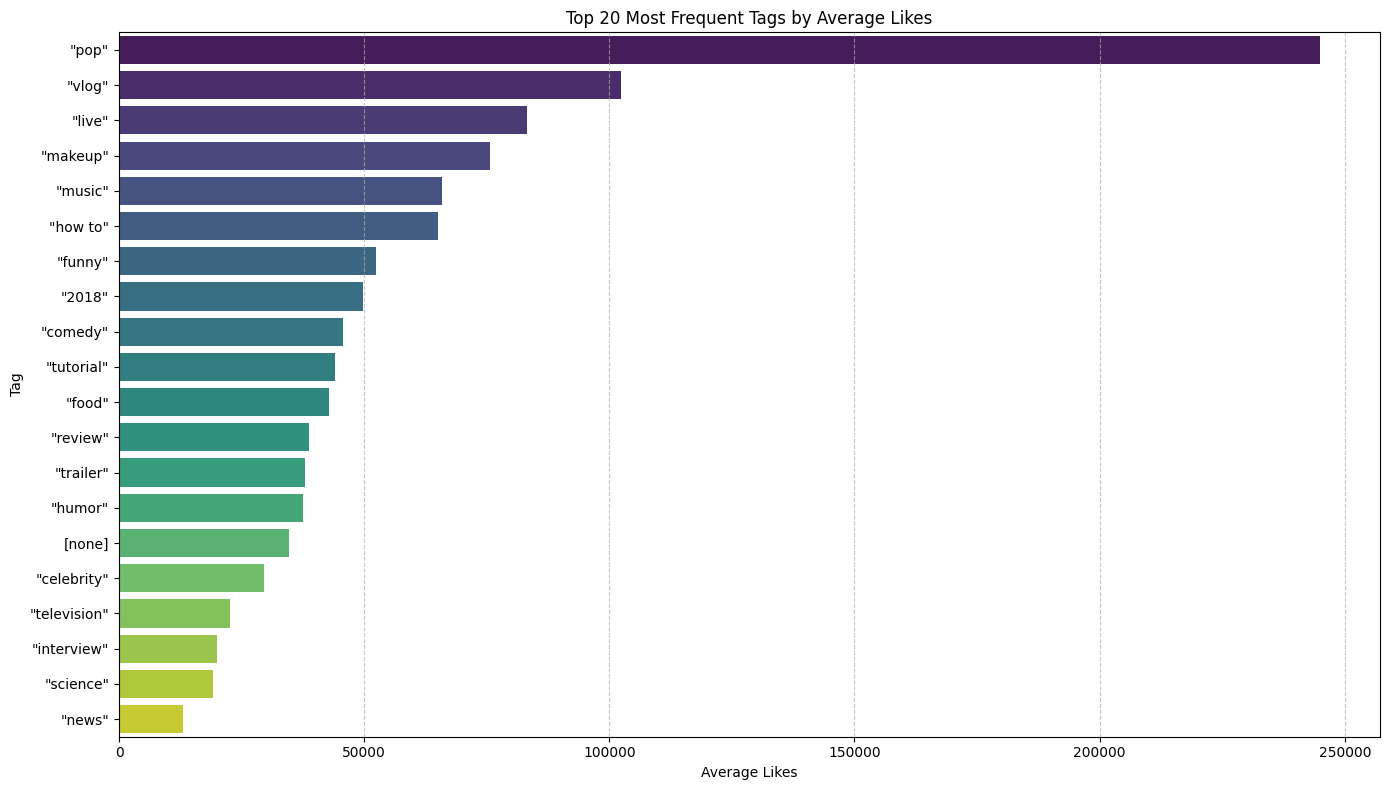

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the relationship between top tags and average likes
plt.figure(figsize=(14, 8))
sns.barplot(x='average_likes', y='tag', data=df_top_tags_avg_likes, palette='viridis')
plt.title('Top 20 Most Frequent Tags by Average Likes')
plt.xlabel('Average Likes')
plt.ylabel('Tag')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

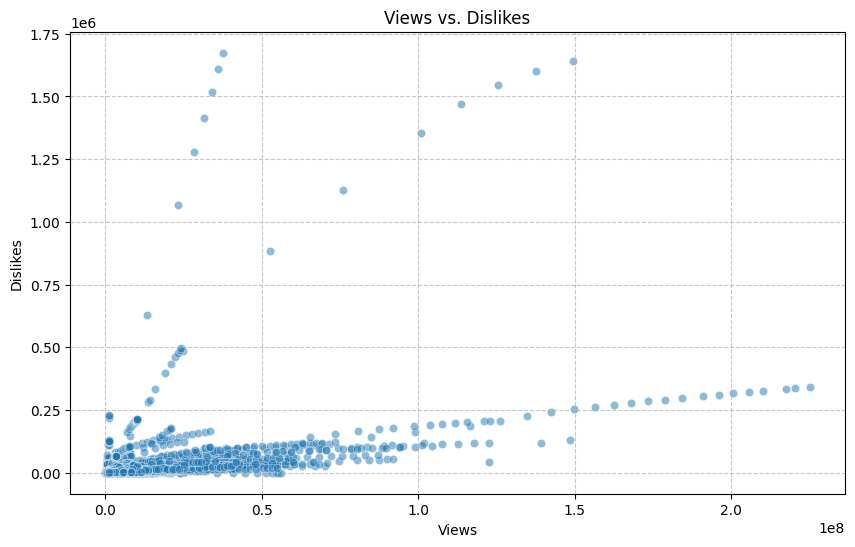

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'views' and 'dislikes' are numeric and handle NaNs, though this was done in the previous step.
# For safety, we'll re-run the conversion and cleaning if needed, using the 'df_cleaned_dislikes' from the last step.
# If running this cell independently, ensure df is loaded and 'views', 'dislikes' are numeric.

# Create a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='views', y='dislikes', data=df_cleaned_dislikes, alpha=0.5)
plt.title('Views vs. Dislikes')
plt.xlabel('Views')
plt.ylabel('Dislikes')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [6]:
# Convert 'dislikes' column to numeric, coercing errors to NaN
df['dislikes'] = pd.to_numeric(df['dislikes'], errors='coerce')

# Drop rows where 'views' or 'dislikes' might have become NaN after conversion
df_cleaned_dislikes = df.dropna(subset=['views', 'dislikes'])

# Calculate and print the correlation coefficient between views and dislikes
correlation_dislikes = df_cleaned_dislikes['views'].corr(df_cleaned_dislikes['dislikes'])
print(f"The correlation between views and dislikes is: {correlation_dislikes:.2f}")

The correlation between views and dislikes is: 0.47


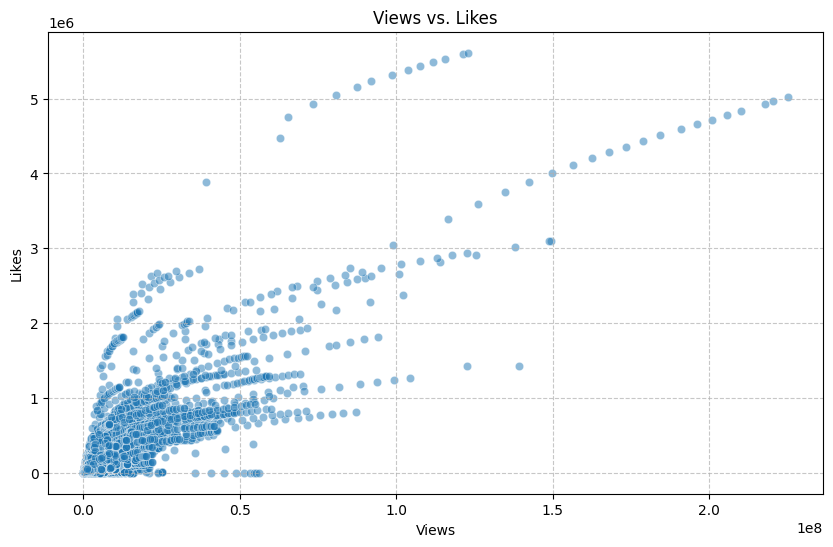

The correlation between views and likes is: 0.85


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'views' and 'likes' columns to numeric, coercing errors to NaN
df['views'] = pd.to_numeric(df['views'], errors='coerce')
df['likes'] = pd.to_numeric(df['likes'], errors='coerce')

# Drop rows where 'views' or 'likes' might have become NaN after conversion
df_cleaned = df.dropna(subset=['views', 'likes'])

# Create a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='views', y='likes', data=df_cleaned, alpha=0.5)
plt.title('Views vs. Likes')
plt.xlabel('Views')
plt.ylabel('Likes')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Calculate and print the correlation coefficient
correlation = df_cleaned['views'].corr(df_cleaned['likes'])
print(f"The correlation between views and likes is: {correlation:.2f}")

In [4]:
import pandas as pd

# Assuming 'path' contains the directory where the dataset files are located.
# We need to find the actual CSV file within that directory.
# Let's inspect the 'path' content to find the CSV file.

import os

# List contents of the downloaded directory
print(os.listdir(path))

# Based on common Kaggle dataset structures, a likely CSV file would be named 'USvideos.csv' or similar.
# For this dataset ('youtube-new'), the main data files are typically 'USvideos.csv', 'GBvideos.csv', etc.
# Let's assume we want to load 'USvideos.csv' for now.
# If this is not the correct file, the user can specify which CSV they want to load.

df = pd.read_csv(os.path.join(path, 'USvideos.csv'))
display(df.head())

['GBvideos.csv', 'MXvideos.csv', 'KRvideos.csv', 'MX_category_id.json', 'GB_category_id.json', 'US_category_id.json', 'IN_category_id.json', 'DEvideos.csv', 'KR_category_id.json', 'RU_category_id.json', 'FRvideos.csv', 'USvideos.csv', 'INvideos.csv', 'RUvideos.csv', 'CA_category_id.json', 'DE_category_id.json', 'JP_category_id.json', 'JPvideos.csv', 'FR_category_id.json', 'CAvideos.csv']


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...
